# 🎧 Spotify Recommendation Project  
## 🚀 by Ssuhaan Jaiin  

This project explores Spotify track data using **unsupervised machine learning** to uncover hidden patterns in music 🎵. By applying techniques like **feature scaling**, **PCA (dimensionality reduction)**, and **K-Means clustering**, the goal is to group similar songs together based on their audio features like danceability, energy, and speechiness.

These clusters help in understanding music styles better and can even act as a foundation for building a simple recommendation system or playlist generator 🔥.

---

This project was built as part of a hands-on workshop hosted by LeWagon, where the focus was on applying machine learning concepts to real-world datasets in a practical and interactive way 💡.

In [14]:
# Data Manipulation
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Scaling
from sklearn.preprocessing import StandardScaler

# Unsupervised Learning
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# The Spotify Dataset

In [15]:
# Load Spotify dataset from URL and preview a random sample of 10 rows
url = "https://spotify-dataset.tiiny.site/Spotify-Dataset.csv"
spotify = pd.read_csv(url)
spotify.sample(10)

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
582,"Get Up, Stand Up - Single Version",['Bob Marley & The Wailers'],30,0.742,0.8820,0.676,0,5,0.0779,-7.126,0.3390,80.328
4282,Lloraras,['Tropicalísimo Apache'],36,0.621,0.9260,0.576,0,7,0.2300,-10.819,0.0345,96.569
6478,"If You Leave - From ""Pretty In Pink""",['Orchestral Manoeuvres In The Dark'],41,0.636,0.9100,0.757,0,0,0.1460,-8.686,0.0326,120.256
3991,Binibi Rocha - Live,['Andrew E.'],41,0.978,0.9660,0.837,0,7,0.7010,-9.806,0.1360,120.120
1836,Now and Then,['Kenny Loggins'],22,0.283,0.2650,0.117,0,3,0.1090,-15.988,0.0389,142.314
7492,You'll Never Walk Alone - Mono; 2002 Remaster,['Gerry & The Pacemakers'],56,0.484,0.2850,0.265,0,0,0.1490,-11.101,0.0322,113.564
490,I'm Gonna Run Away from You,['Tami Lynn'],45,0.814,0.9030,0.493,0,10,0.2650,-9.433,0.0729,136.628
493,All the Money,['Bobby Charles'],21,0.503,0.4490,0.302,0,4,0.1320,-15.833,0.0905,106.853
7246,Feathers,['Coheed and Cambria'],41,0.551,0.7000,0.966,0,9,0.0858,-2.809,0.0597,132.937
6792,Les Mémoires Blessées,['Dark Sanctuary'],41,0.619,0.0369,0.170,0,8,0.0675,-17.802,0.0275,139.935


## Basic Information

In [16]:
# Display dataset structure, column types, and missing values
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          10000 non-null  object 
 1   artists       10000 non-null  object 
 2   popularity    10000 non-null  int64  
 3   danceability  10000 non-null  float64
 4   valence       10000 non-null  float64
 5   energy        10000 non-null  float64
 6   explicit      10000 non-null  int64  
 7   key           10000 non-null  int64  
 8   liveness      10000 non-null  float64
 9   loudness      10000 non-null  float64
 10  speechiness   10000 non-null  float64
 11  tempo         10000 non-null  float64
dtypes: float64(7), int64(3), object(2)
memory usage: 937.6+ KB


## The Numerical Information

In [17]:
# Select only numerical columns for analysis and modeling
spotify_numerical = spotify.select_dtypes(include=['number'])
spotify_numerical

,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716
...,...,...,...,...,...,...,...,...,...,...
9995,72,0.786,0.608,0.808,0,7,0.0822,-3.702,0.0881,105.029
9996,68,0.717,0.734,0.753,0,7,0.1010,-6.020,0.0605,137.936
9997,76,0.634,0.637,0.858,0,4,0.2580,-2.226,0.0809,91.688
9998,70,0.671,0.195,0.623,1,2,0.6430,-7.161,0.3080,75.055


## Visualise the correlation between the features

In [18]:
# Compute correlation matrix to understand relationships between numerical features
spotify_numerical.corr()



,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
popularity,1.000000,0.158167,-0.127786,0.071411,0.253155,0.002372,-0.096146,0.262113,0.111443,-0.000034
danceability,0.158167,1.000000,0.535965,0.135900,0.222807,0.020529,-0.138549,0.270200,0.181405,-0.098558
valence,-0.127786,0.535965,1.000000,0.334797,-0.028789,0.013882,-0.023028,0.277637,0.036870,0.112265
energy,0.071411,0.135900,0.334797,1.000000,0.125157,0.031190,0.195959,0.748498,0.159822,0.216206
explicit,0.253155,0.222807,-0.028789,0.125157,1.000000,-0.002785,0.023434,0.178624,0.443932,-0.019365
key,0.002372,0.020529,0.013882,0.031190,-0.002785,1.000000,-0.000416,0.026998,0.020509,0.005963
liveness,-0.096146,-0.138549,-0.023028,0.195959,0.023434,-0.000416,1.000000,0.084811,0.162604,0.035392
loudness,0.262113,0.270200,0.277637,0.748498,0.178624,0.026998,0.084811,1.000000,0.107819,0.189482
speechiness,0.111443,0.181405,0.036870,0.159822,0.443932,0.020509,0.162604,0.107819,1.000000,0.003390
tempo,-0.000034,-0.098558,0.112265,0.216206,-0.019365,0.005963,0.035392,0.189482,0.003390,1.000000


### Use PuRd Visualisation
Uses the PuRd (Purple-Red) color palette to enhance clarity and highlight correlation intensity in the visualization.

<Axes: >

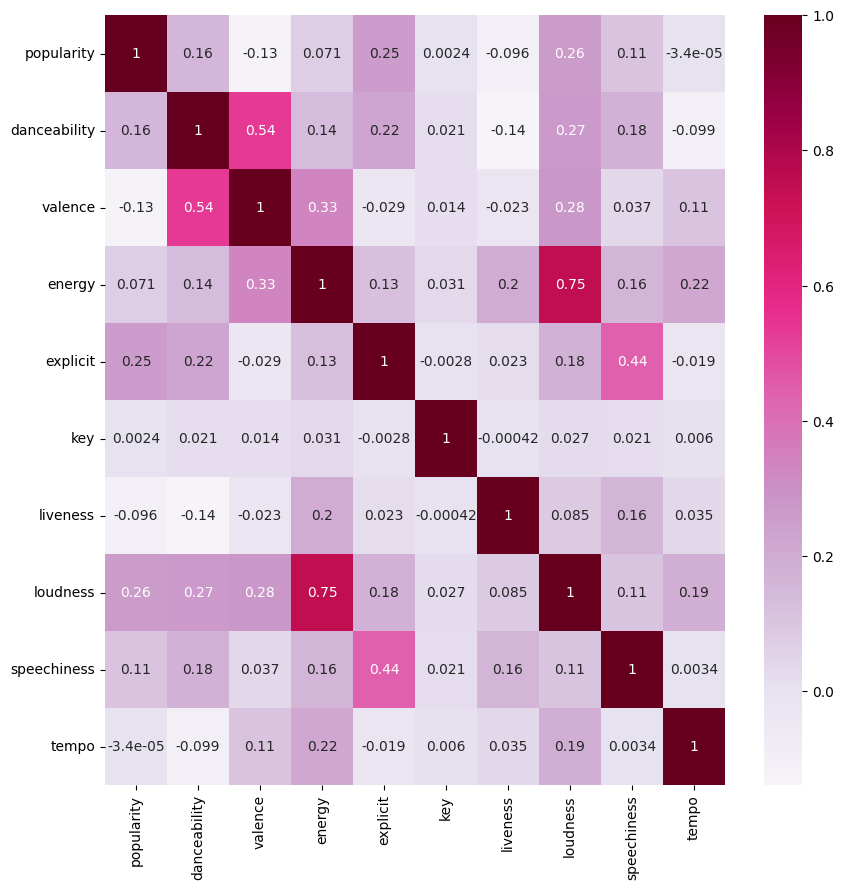

In [19]:
# Visualize feature correlations using a heatmap
plt.figure(figsize=(10,10))
sns.heatmap(spotify_numerical.corr(), annot=True, cmap="PuRd")

## 3D Visualisation
Explores relationships between key audio features in a 3D space to identify patterns and potential groupings in the data.

In [20]:
# Create an interactive 3D scatter plot of key audio features
px.scatter_3d(spotify_numerical, x="danceability", y="energy", z="speechiness")

# Unsupervised Learning - Clustering
Clustering is an unsupervised machine learning technique that groups data points based on their similarity, without using predefined labels. The goal is to organize the data into clusters such that points within the same group are more similar to each other than to those in different groups.

In [21]:
# Apply K-Means clustering (k=8) and visualize clusters in 3D feature space
kmeans_1 = KMeans(n_clusters=8)
kmeans_1.fit(spotify_numerical)
kmeans_1.labels_

px.scatter_3d(
    spotify_numerical,
    x="danceability",
    y="energy",
    z="speechiness",
    color=kmeans_1.labels_
)

## Scaling + KMeans
Uses Standard Scaling (Z-score normalization) to transform the data so that each feature has a mean of 0 and a standard deviation of 1. This ensures that all variables are on the same scale, preventing features with larger values (like tempo or loudness) from dominating the clustering process and allowing K-Means to form more balanced and meaningful clusters.

In [22]:
# Standardize numerical features to ensure equal contribution to clustering
scaler = StandardScaler().set_output(transform="pandas")
spotify_scaled = scaler.fit_transform(spotify_numerical)
spotify_scaled

,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,-1.238686,0.721511,0.137131,-0.637854,-0.339228,-0.619225,-0.707788,-0.540084,-0.478030,-0.082809
1,-0.999816,-0.525061,-1.010349,-0.892028,-0.339228,0.223029,-0.277705,-0.163448,-0.531779,0.780035
2,-1.318309,-0.654211,1.185161,0.521816,-0.339228,-1.461479,-0.205422,0.003632,-0.434235,-1.184390
3,-1.238686,-0.637365,1.326684,1.276395,-0.339228,-0.057722,3.331277,0.538890,-0.203313,1.778805
4,-1.159063,0.670974,0.156255,-0.717283,-0.339228,0.503780,0.987246,-0.615072,-0.134634,-1.370283
...,...,...,...,...,...,...,...,...,...,...
9995,2.742486,1.327952,0.324552,0.855420,-0.339228,0.503780,-0.658739,1.150264,0.066427,-0.500697
9996,2.423992,0.940504,0.806493,0.636989,-0.339228,0.503780,-0.561673,0.714615,-0.208290,0.586805
9997,3.060980,0.474443,0.435475,1.053993,-0.339228,-0.338474,0.248928,1.427666,-0.005238,-0.941588
9998,2.583239,0.682205,-1.255144,0.120697,2.947867,-0.899976,2.236707,0.500174,2.255203,-1.491271


In [23]:
# Apply K-Means (k=6) on scaled data and visualize resulting clusters
kmeans_2 = KMeans(n_clusters=6)
kmeans_2.fit(spotify_scaled)

px.scatter_3d(
    spotify_numerical,
    x="danceability",
    y="energy",
    z="speechiness",
    color=kmeans_2.labels_
)

## Scaling + PCA + KMeans
Combines feature scaling, dimensionality reduction, and clustering to improve model performance and reveal clearer, more meaningful groupings in the data.



In [24]:
# Apply PCA to reduce dimensionality while preserving variance in the data
pca = PCA().set_output(transform="pandas")
spotify_projected = pca.fit_transform(spotify_numerical)
spotify_projected

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9
0,-2.616928,-15.788176,-0.814619,-2.155956,0.010845,0.104717,-0.201103,-0.054319,0.092980,-0.032004
1,23.549661,-12.686149,-0.005836,0.792204,-0.055659,-0.305376,-0.224453,-0.144817,0.016247,-0.014662
2,-35.832830,-16.230595,3.209500,-5.287428,-0.045820,0.189411,0.050592,0.166356,-0.177144,0.003917
3,53.880790,-15.333388,3.050128,-0.344312,0.003409,0.076882,0.621717,-0.151562,-0.095798,-0.057971
4,-41.561795,-14.640036,0.138134,1.837601,0.006046,0.067157,0.108622,-0.191989,0.061726,-0.025046
...,...,...,...,...,...,...,...,...,...,...
9995,-14.903243,35.028133,2.147568,1.684640,-0.309440,0.234882,-0.010780,0.064162,0.105752,0.001860
9996,17.901623,30.586175,-0.741913,1.776399,-0.257397,0.335599,0.023568,0.062826,0.025355,-0.015706
9997,-28.184495,39.252610,3.425387,-1.361744,-0.368684,0.161020,0.180374,0.046534,-0.040004,0.008203
9998,-44.984186,32.751297,-0.190290,-3.205730,0.711163,-0.305547,0.387957,-0.185421,0.065600,0.036196


In [25]:
# Apply K-Means on PCA-transformed data and visualize clusters in reduced dimensions
kmeans_3 = KMeans(n_clusters=6)
kmeans_3.fit(spotify_projected)

px.scatter_3d(
    spotify_projected,
    x="pca0",
    y="pca1",
    z="pca2",
    color=kmeans_3.labels_
)

##Displaying Playlist 6

In [26]:
# Assign cluster labels to original dataset and filter songs from a specific cluster
spotify["playlist_number"] = kmeans_3.labels_
spotify[spotify["playlist_number"] == 5]

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo,playlist_number
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674,5
5,For Some We Loved,['Dorothy Ashby'],22,0.467,0.567,0.233,0,5,0.1840,-15.141,0.0374,108.363,5
6,Yeh Sham Mastani (with Dialogues),"['Kishore Kumar', 'Rajesh Khanna', 'Asha Parekh']",23,0.438,0.551,0.312,0,6,0.0929,-14.050,0.0518,116.365,5
7,Isn't It Quiet And Cold,['Gentle Giant'],28,0.739,0.612,0.106,0,2,0.2740,-21.272,0.0537,109.297,5
10,Morning Colors,['Linda Perhacs'],22,0.399,0.187,0.155,0,2,0.1060,-12.986,0.0334,110.768,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9860,Tomar Dyakha Naai,['Arijit Singh'],1,0.637,0.536,0.892,0,0,0.0699,-5.477,0.0379,104.004,5
9863,Hoye Jetey Paari,['Arijit Singh'],1,0.693,0.185,0.725,0,2,0.1020,-6.426,0.0878,123.959,5
9864,Jodi Bolo,['Arijit Singh'],0,0.420,0.394,0.682,0,11,0.1620,-6.565,0.0410,112.009,5
9891,Power,"['Kevin Gates', 'Dermot Kennedy']",34,0.591,0.322,0.616,0,7,0.1440,-6.883,0.0789,125.990,5


Compares a smaller number of clusters (6) with a much larger one (200) to evaluate the trade-off between broader groupings and highly specific, fine grained segmentation of songs.


In [27]:
# Apply K-Means with a large number of clusters (k=200) to create highly granular groupings
kmeans_4 = KMeans(n_clusters=200)
kmeans_4.fit(spotify_projected)

px.scatter_3d(
    spotify_projected,
    x="pca0",
    y="pca1",
    z="pca2",
    color=kmeans_4.labels_
)

In [1]:
# Final K-Means model (k=6) applied on PCA-reduced data for optimal clustering
kmeans_5 = KMeans(n_clusters=6)
kmeans_5.fit(spotify_projected)

px.scatter_3d(
    spotify_projected,
    x="pca0",
    y="pca1",
    z="pca2",
    color=kmeans_5.labels_
)

NameError: name 'KMeans' is not defined

# My Learnings

## Definitions
### Unsupervised Learning  
*A type of machine learning where the model learns patterns from data without any labeled outputs.*
### Clustering
*A technique used to group similar data points together based on their features without predefined labels.*
### K-Means Clustering
*An algorithm that divides data into K clusters by minimizing the distance between data points and their cluster centroids.*
### PCA (Principal Component Analysis)
*A dimensionality reduction technique that transforms data into a smaller set of components while preserving most of the variance.*
### Feature Scaling (Standardization)
*A preprocessing step that transforms features so they have a mean of 0 and a standard deviation of 1, ensuring all variables contribute equally.*



### Key Takeaways

- Learned how to work with real-world music data and perform basic data exploration using Python libraries like pandas and NumPy.  
- Understood the importance of **feature scaling** to ensure all variables contribute equally in machine learning models.  
- Gained hands-on experience with **PCA (Principal Component Analysis)** for dimensionality reduction and visualization.  
- Applied **K-Means clustering** to group similar Spotify tracks based on audio features like danceability, energy, and speechiness.  
- Experimented with different numbers of clusters to understand how it affects the granularity and interpretation of results.  




### Summary

Overall, this project helped me understand the end to end workflow of an unsupervised machine learning pipeline from data preprocessing and transformation to clustering and visualization.


